In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu gốc
df = pd.read_csv("../data/raw/train.csv")

# === Làm sạch dữ liệu (lặp lại các bước đã làm) ===
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True, errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True, errors="coerce")

# Xử lý giá trị thiếu Postal Code
df = df.dropna(subset=["Postal Code"]).copy()

# Tạo các cột thời gian
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df["Quarter"] = df["Order Date"].dt.quarter
df["DayOfWeek"] = df["Order Date"].dt.day_name()

# Thiết lập style biểu đồ
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Kiểm tra
print("Kích thước dữ liệu:", df.shape)
print("Các cột hiện có:", df.columns.tolist())
print("\n5 dòng đầu:")
display(df.head())

Kích thước dữ liệu: (9789, 22)
Các cột hiện có: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Year', 'Month', 'Quarter', 'DayOfWeek']

5 dòng đầu:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Quarter,DayOfWeek
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,4,Wednesday
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,4,Wednesday
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,2,Monday
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,4,Tuesday
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,4,Tuesday


In [4]:
print("=== TỔNG QUAN DOANH THU ===")
print(f"Tổng doanh thu        : {df['Sales'].sum():,.2f}")
print(f"Doanh thu trung bình  : {df['Sales'].mean():,.2f}")
print(f"Doanh thu trung vị    : {df['Sales'].median():,.2f}")
print(f"Doanh thu cao nhất    : {df['Sales'].max():,.2f}")
print(f"Doanh thu thấp nhất   : {df['Sales'].min():,.2f}")
print(f"Độ lệch chuẩn         : {df['Sales'].std():,.2f}")

=== TỔNG QUAN DOANH THU ===
Tổng doanh thu        : 2,252,607.41
Doanh thu trung bình  : 230.12
Doanh thu trung vị    : 54.38
Doanh thu cao nhất    : 22,638.48
Doanh thu thấp nhất   : 0.44
Độ lệch chuẩn         : 625.30


                 Tổng doanh thu  Doanh thu TB  Số đơn hàng
Category                                                  
Technology            825856.11        456.27         1810
Furniture             723538.48        348.53         2076
Office Supplies       703212.82        119.13         5903


C:\Users\viloc\AppData\Local\Temp\ipykernel_21136\1628715765.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_sales.index, y=category_sales["Tổng doanh thu"], palette="Blues_d")


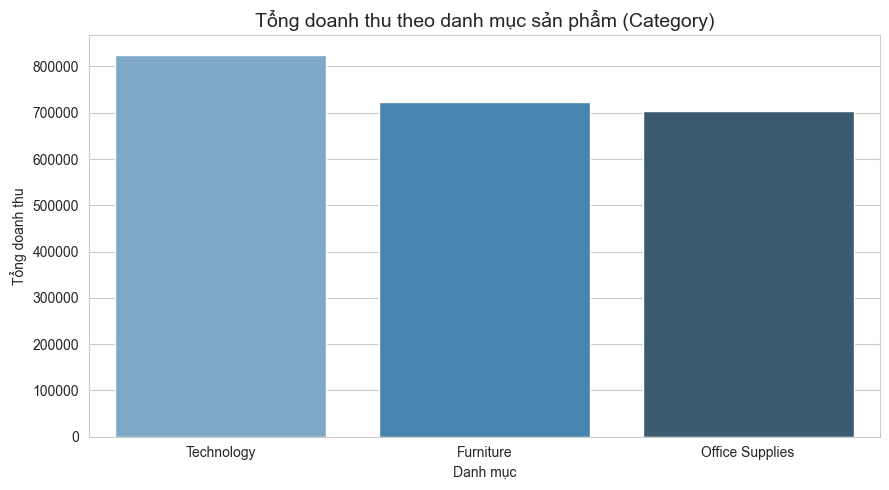

In [5]:
category_sales = df.groupby("Category")["Sales"].agg(["sum", "mean", "count"]).round(2)
category_sales.columns = ["Tổng doanh thu", "Doanh thu TB", "Số đơn hàng"]
category_sales = category_sales.sort_values("Tổng doanh thu", ascending=False)
print(category_sales)

plt.figure(figsize=(9, 5))
sns.barplot(x=category_sales.index, y=category_sales["Tổng doanh thu"], palette="Blues_d")
plt.title("Tổng doanh thu theo danh mục sản phẩm (Category)", fontsize=14)
plt.ylabel("Tổng doanh thu")
plt.xlabel("Danh mục")
plt.tight_layout()
plt.savefig("../reports/figures/01_sales_by_category.png", dpi=150)
plt.show()

         Tổng doanh thu  Doanh thu TB  Số đơn hàng
Region                                            
West          710219.68        226.18         3140
East          660589.36        238.14         2774
Central       492646.91        216.36         2277
South         389151.46        243.52         1598


C:\Users\viloc\AppData\Local\Temp\ipykernel_21136\765328573.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_sales.index, y=region_sales["Tổng doanh thu"], palette="Greens_d")


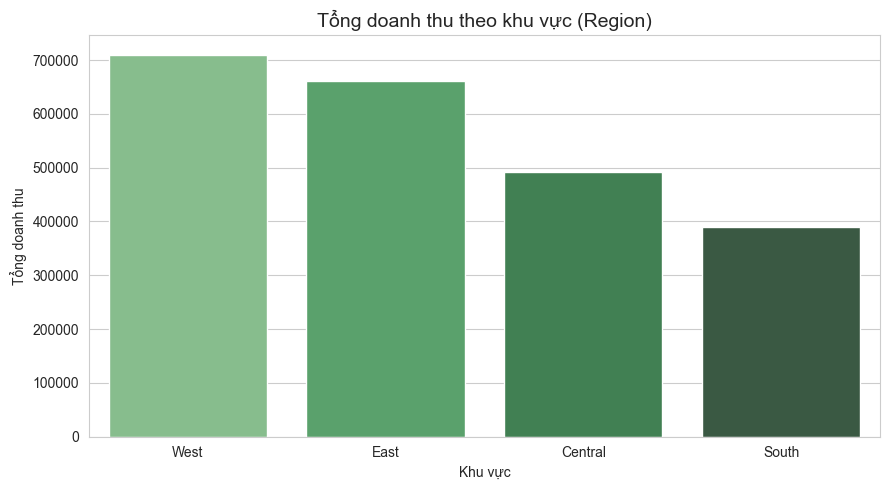

In [6]:
region_sales = df.groupby("Region")["Sales"].agg(["sum", "mean", "count"]).round(2)
region_sales.columns = ["Tổng doanh thu", "Doanh thu TB", "Số đơn hàng"]
region_sales = region_sales.sort_values("Tổng doanh thu", ascending=False)
print(region_sales)

plt.figure(figsize=(9, 5))
sns.barplot(x=region_sales.index, y=region_sales["Tổng doanh thu"], palette="Greens_d")
plt.title("Tổng doanh thu theo khu vực (Region)", fontsize=14)
plt.ylabel("Tổng doanh thu")
plt.xlabel("Khu vực")
plt.tight_layout()
plt.savefig("../reports/figures/02_sales_by_region.png", dpi=150)
plt.show()

             Tổng doanh thu  Doanh thu TB  Số đơn hàng
Segment                                               
Consumer         1146708.15        225.02         5096
Corporate         682211.83        231.42         2948
Home Office       423687.43        242.80         1745


C:\Users\viloc\AppData\Local\Temp\ipykernel_21136\1133146264.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_sales.index, y=segment_sales["Tổng doanh thu"], palette="Oranges_d")


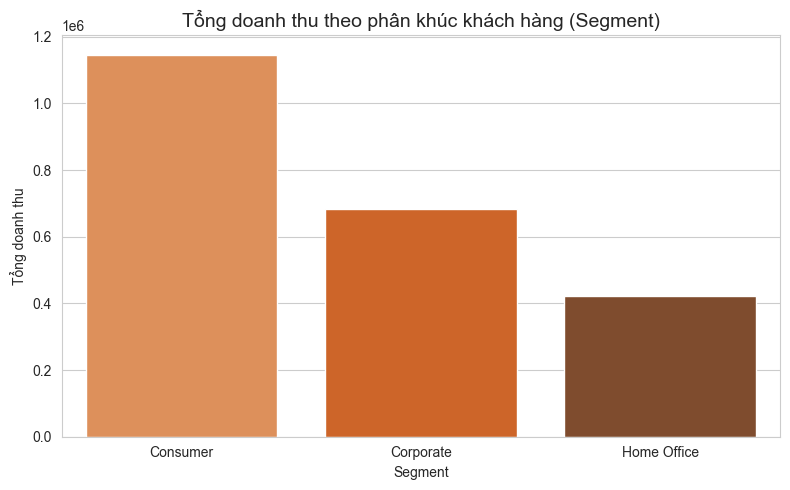

In [7]:
segment_sales = df.groupby("Segment")["Sales"].agg(["sum", "mean", "count"]).round(2)
segment_sales.columns = ["Tổng doanh thu", "Doanh thu TB", "Số đơn hàng"]
segment_sales = segment_sales.sort_values("Tổng doanh thu", ascending=False)
print(segment_sales)

plt.figure(figsize=(8, 5))
sns.barplot(x=segment_sales.index, y=segment_sales["Tổng doanh thu"], palette="Oranges_d")
plt.title("Tổng doanh thu theo phân khúc khách hàng (Segment)", fontsize=14)
plt.ylabel("Tổng doanh thu")
plt.tight_layout()
plt.savefig("../reports/figures/03_sales_by_segment.png", dpi=150)
plt.show()

Doanh thu theo năm:
Year
2015    479856.21
2016    454315.91
2017    597225.49
2018    721209.81
Name: Sales, dtype: float64


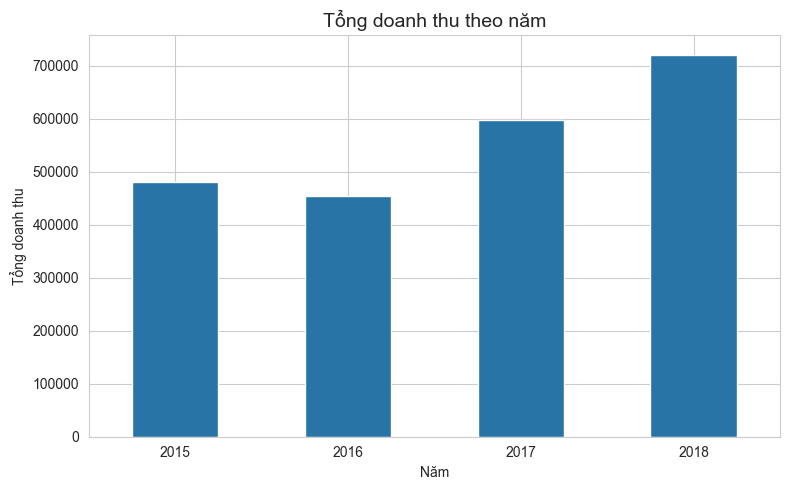

In [8]:
yearly = df.groupby("Year")["Sales"].sum().round(2)
print("Doanh thu theo năm:")
print(yearly)

plt.figure(figsize=(8, 5))
yearly.plot(kind="bar", color="#2874A6")
plt.title("Tổng doanh thu theo năm", fontsize=14)
plt.ylabel("Tổng doanh thu")
plt.xlabel("Năm")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../reports/figures/04_sales_by_year.png", dpi=150)
plt.show()

Doanh thu theo tháng:
Month
1      91982.14
2      59371.12
3     197573.59
4     134988.25
5     154086.72
6     145837.52
7     145535.69
8     157315.93
9     300103.41
10    199496.29
11    345041.61
12    321275.14
Name: Sales, dtype: float64


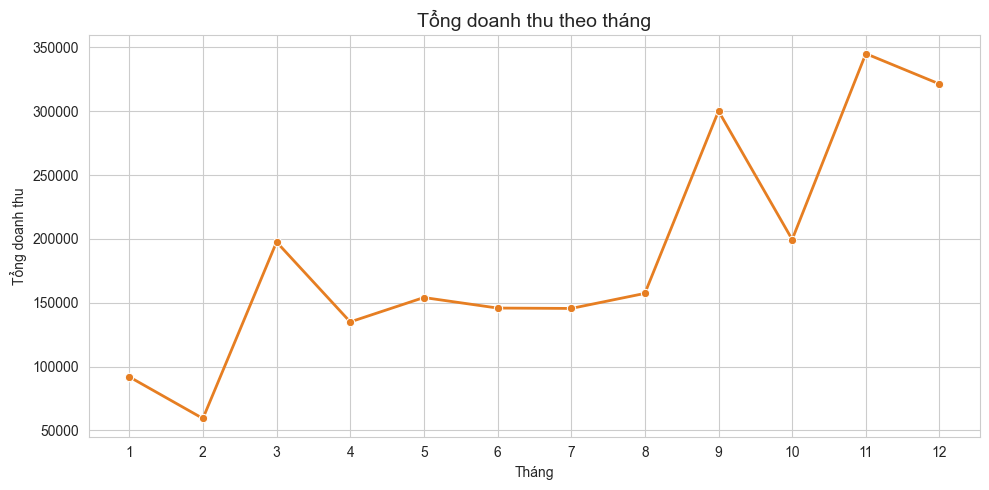

In [9]:
monthly = df.groupby("Month")["Sales"].sum().round(2)
print("Doanh thu theo tháng:")
print(monthly)

plt.figure(figsize=(10, 5))
sns.lineplot(x=monthly.index, y=monthly.values, marker="o", color="#E67E22", linewidth=2)
plt.title("Tổng doanh thu theo tháng", fontsize=14)
plt.ylabel("Tổng doanh thu")
plt.xlabel("Tháng")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.savefig("../reports/figures/05_sales_by_month.png", dpi=150)
plt.show()

Quarter
1    348926.84
2    434912.50
3    602955.03
4    865813.05
Name: Sales, dtype: float64


C:\Users\viloc\AppData\Local\Temp\ipykernel_21136\1061731540.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=quarterly.index, y=quarterly.values, palette="Purples_d")


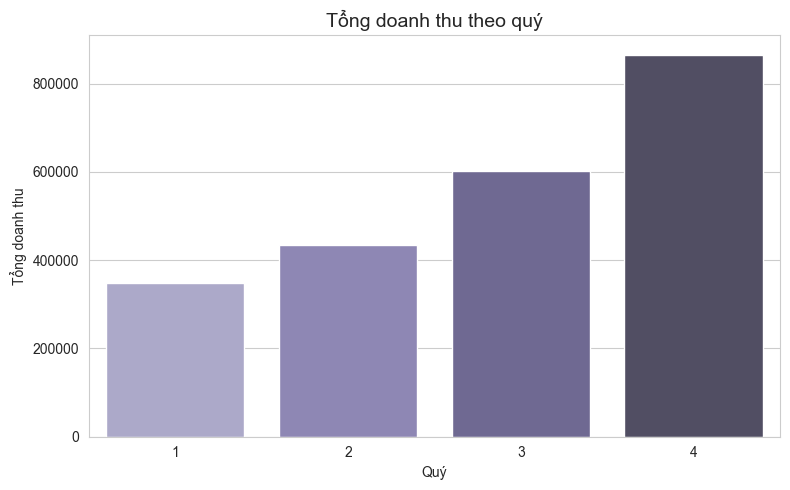

In [10]:
quarterly = df.groupby("Quarter")["Sales"].sum().round(2)
print(quarterly)

plt.figure(figsize=(8, 5))
sns.barplot(x=quarterly.index, y=quarterly.values, palette="Purples_d")
plt.title("Tổng doanh thu theo quý", fontsize=14)
plt.ylabel("Tổng doanh thu")
plt.xlabel("Quý")
plt.tight_layout()
plt.savefig("../reports/figures/06_sales_by_quarter.png", dpi=150)
plt.show()

Top 10 Sub-Category theo doanh thu:
Sub-Category
Phones         326487.6980
Chairs         322107.5310
Storage        217779.1020
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    163881.6900
Copiers        146248.0940
Bookcases      109408.2987
Appliances     104075.4630
Name: Sales, dtype: float64


C:\Users\viloc\AppData\Local\Temp\ipykernel_21136\1547935261.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=subcat.values, y=subcat.index, palette="Blues_r")


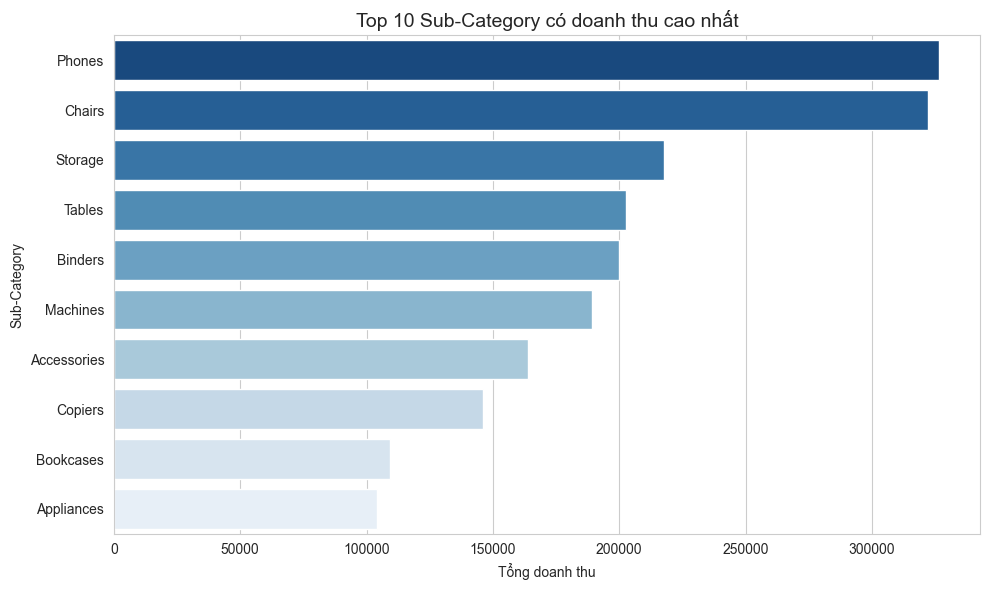

In [11]:
subcat = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).head(10)
print("Top 10 Sub-Category theo doanh thu:")
print(subcat)

plt.figure(figsize=(10, 6))
sns.barplot(x=subcat.values, y=subcat.index, palette="Blues_r")
plt.title("Top 10 Sub-Category có doanh thu cao nhất", fontsize=14)
plt.xlabel("Tổng doanh thu")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.savefig("../reports/figures/07_top10_subcategory.png", dpi=150)
plt.show()

Region            Central      East     South      West
Category                                               
Furniture        160317.0  201341.0  116531.0  245348.0
Office Supplies  163590.0  197731.0  124425.0  217467.0
Technology       168739.0  261517.0  148195.0  247405.0


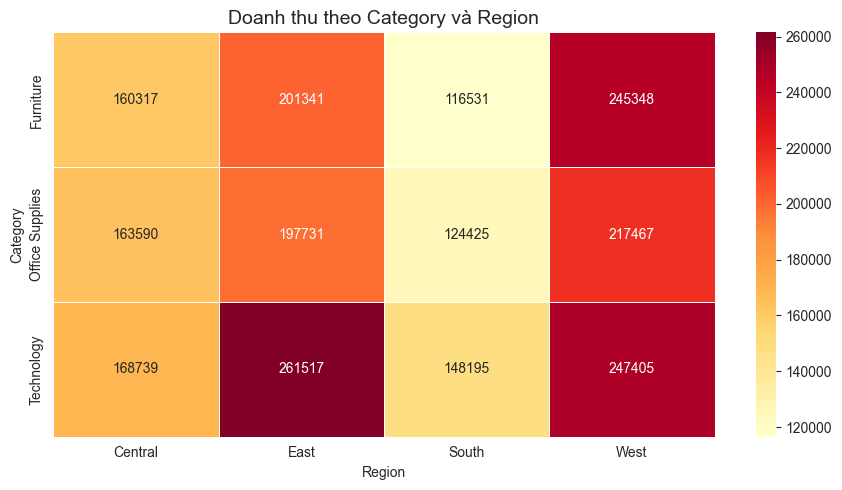

In [12]:
pivot = df.pivot_table(values="Sales", index="Category", columns="Region", aggfunc="sum").round(0)
print(pivot)

plt.figure(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5)
plt.title("Doanh thu theo Category và Region", fontsize=14)
plt.tight_layout()
plt.savefig("../reports/figures/08_heatmap_category_region.png", dpi=150)
plt.show()

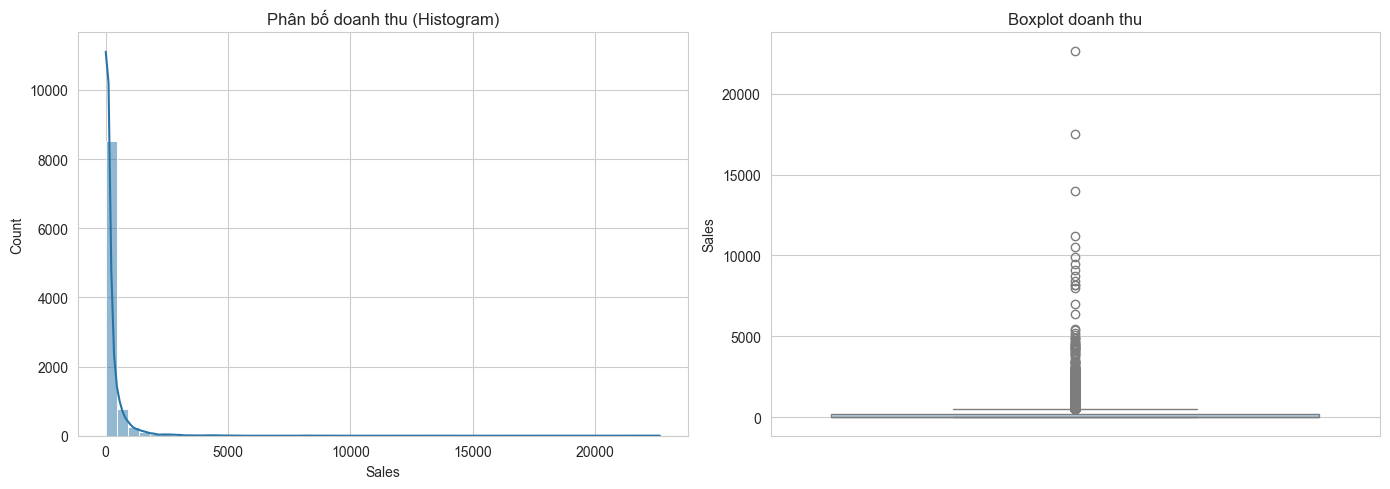

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Sales"], bins=50, kde=True, ax=axes[0], color="#2874A6")
axes[0].set_title("Phân bố doanh thu (Histogram)")
axes[0].set_xlabel("Sales")

sns.boxplot(y=df["Sales"], ax=axes[1], color="#AED6F1")
axes[1].set_title("Boxplot doanh thu")

plt.tight_layout()
plt.savefig("../reports/figures/09_sales_distribution.png", dpi=150)
plt.show()